In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('german_credit_data.csv')
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [4]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [5]:
# Removing Column ('Unnamed: 0')
df.drop('Unnamed: 0', axis=1, inplace=True)

In [6]:
# Filling Missing Values with 'unknown'
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [7]:
# Capitalizing Values
categorical_columns = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical_columns:
    df[col] = df[col].str.title()
    print(f'\nValue Counts of {col}:')
    print(df[col].value_counts(normalize=True) * 100)


Value Counts of Sex:
Sex
Male      69.0
Female    31.0
Name: proportion, dtype: float64

Value Counts of Housing:
Housing
Own     71.3
Rent    17.9
Free    10.8
Name: proportion, dtype: float64

Value Counts of Saving accounts:
Saving accounts
Little        60.3
Unknown       18.3
Moderate      10.3
Quite Rich     6.3
Rich           4.8
Name: proportion, dtype: float64

Value Counts of Checking account:
Checking account
Unknown     39.4
Little      27.4
Moderate    26.9
Rich         6.3
Name: proportion, dtype: float64

Value Counts of Purpose:
Purpose
Car                    33.7
Radio/Tv               28.0
Furniture/Equipment    18.1
Business                9.7
Education               5.9
Repairs                 2.2
Domestic Appliances     1.2
Vacation/Others         1.2
Name: proportion, dtype: float64


In [13]:
df.rename(columns={'Saving accounts': 'Saving Accounts',
                  'Checking account': 'Checking Account',
                  'Credit amount': 'Credit Amount'}, inplace=True)
df

,Age,Sex,Job,Housing,Saving Accounts,Checking Account,Credit Amount,Duration,Purpose
0,67,Male,2,Own,Unknown,Little,1169,6,Radio/Tv
1,22,Female,2,Own,Little,Moderate,5951,48,Radio/Tv
2,49,Male,1,Own,Little,Unknown,2096,12,Education
3,45,Male,2,Free,Little,Little,7882,42,Furniture/Equipment
4,53,Male,2,Free,Little,Little,4870,24,Car
...,...,...,...,...,...,...,...,...,...
995,31,Female,1,Own,Little,Unknown,1736,12,Furniture/Equipment
996,40,Male,3,Own,Little,Little,3857,30,Car
997,38,Male,2,Own,Little,Unknown,804,12,Radio/Tv
998,23,Male,2,Free,Little,Little,1845,45,Radio/Tv


In [15]:
# Summary Statistics of Numerical Column
df[['Age', 'Credit Amount', 'Duration']].describe()

,Age,Credit Amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000
std,11.375469,2822.736876,12.058814
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,75.000000,18424.000000,72.000000


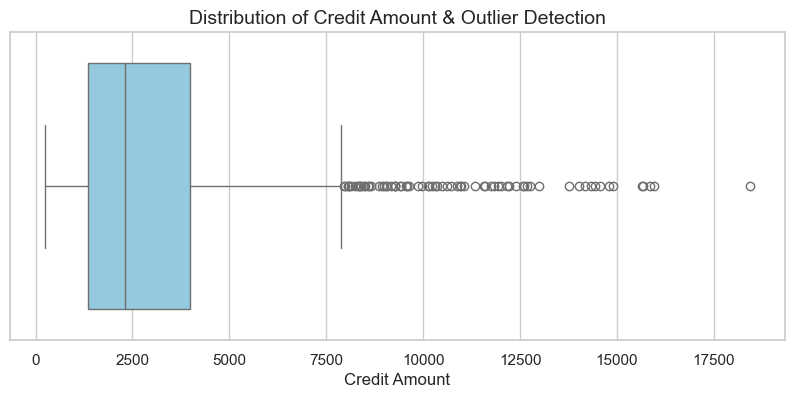

In [96]:
# Visualizing the Outliers with a Boxplot
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(df, x='Credit Amount', color='skyblue', ax=ax)
ax.set_title('Distribution of Credit Amount & Outlier Detection', fontsize=14)
ax.set_xlabel('Credit Amount', fontsize=12)
plt.show()

In [97]:
df[['Age', 'Credit amount', 'Duration']].corr()

,Age,Credit amount,Duration
Age,1.000000,0.032716,-0.036136
Credit amount,0.032716,1.000000,0.624984
Duration,-0.036136,0.624984,1.000000


In [98]:
df.to_csv('german_credit_data_clean.csv', index=False)
print("Phase 3 Complete: Clean dataset exported successfully!")

Phase 3 Complete: Clean dataset exported successfully!
